# 🔬 Análisis Exploratorio de Datos (EDA) Avanzado
## Proyecto: Predicción de Cáncer Bucal Histopatológico

Este notebook realiza un análisis exhaustivo del dataset de imágenes histopatológicas para cuantificar la calidad de los datos, identificar sesgos de clase y extraer características estadísticas que guiarán el preprocesamiento y entrenamiento.

### Objetivos:
1.  **Consolidación**: Unificar `train`, `test` y `val` en un solo flujo de análisis.
2.  **Calidad**: Identificar imágenes corruptas, oscuras o de bajo contraste.
3.  **Dimensiones**: Analizar la variabilidad de resolución (100x vs 400x).
4.  **Colorimetría**: Cuantificar perfiles RGB por clase.
5.  **Inferencia**: Validar diferencias estadísticas entre clases (Normal vs OSCC).

---
## 1. Configuración de Entorno y Estilo

In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mimetypes
from PIL import Image, ImageStat
from tqdm.auto import tqdm
from scipy import stats
from IPython.display import Markdown, display
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')
tqdm.pandas() # Habilitar progress_apply de pandas

# Configuración visual premium
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.family'] = 'sans-serif'

PALETTE = {"cancer": "#E63946", "normal": "#457B9D", "accent": "#1D3557"}
print("✅ Entorno configurado con éxito.")

✅ Entorno configurado con éxito.


---
## 2. Consolidación del Dataset
Escaneamos las carpetas para construir el DataFrame maestro.

In [38]:
DATA_DIR = 'data'
subsets = ['train', 'test', 'val']

data_records = []
for subset in subsets:
    subset_path = os.path.join(DATA_DIR, subset)
    if not os.path.exists(subset_path): continue
    
    for class_name in os.listdir(subset_path):
        class_path = os.path.join(subset_path, class_name)
        if not os.path.isdir(class_path): continue
        
        for img_name in os.listdir(class_path):
            data_records.append({
                'filepath': os.path.join(class_path, img_name),
                'class_name': class_name,
                'subset': subset,
                'label': 1 if 'OSCC' in class_name.upper() else 0
            })

df = pd.DataFrame(data_records)
print(f"📊 Total de imágenes encontradas: {len(df)}")
print(df.groupby(['subset', 'class_name']).size().unstack(fill_value=0))

📊 Total de imágenes encontradas: 5192
class_name  Normal  OSCC
subset                  
test            31    95
train         2435  2511
val             28    92


---
## 3. Extracción de Metadatos y Calidad
Procesamos las imágenes para obtener dimensiones, perfiles de color y diagnosticar integridad.

In [39]:
def extract_metadata(filepath):
    try:
        with Image.open(filepath) as img:
            w, h = img.size
            # Asegurar modo RGB para uniformidad
            if img.mode != 'RGB':
                img = img.convert('RGB')
            
            # Estadísticas de color
            stat = ImageStat.Stat(img)
            r_mean, g_mean, b_mean = stat.mean
            
            # Brillo y contraste aproximado
            brightness = sum(stat.mean) / 3
            contrast = sum(stat.stddev) / 3
            
            return pd.Series({
                'width': w, 'height': h, 
                'aspect_ratio': w/h,
                'mean_r': r_mean, 'mean_g': g_mean, 'mean_b': b_mean,
                'brightness': brightness, 'contrast': contrast,
                'megapixels': (w * h) / 1e6,
                'file_size_kb': os.path.getsize(filepath) / 1024,
                'extension': os.path.splitext(filepath)[1].lower(),
                'is_corrupt': False
            })
    except Exception:
        return pd.Series({'is_corrupt': True})

print("⏳ Extrayendo metadatos...")
meta_df = df['filepath'].progress_apply(extract_metadata)
df = pd.concat([df, meta_df], axis=1)

# Filtrar corruptas para el análisis estadístico
df_valid = df[df['is_corrupt'] == False].copy()
print(f"✅ Procesamiento completado. Imágenes válidas: {len(df_valid)}")

⏳ Extrayendo metadatos...


  0%|          | 0/5192 [00:00<?, ?it/s]

✅ Procesamiento completado. Imágenes válidas: 5192


---
## 4. Análisis de Distribución de Clases
¿Está balanceado el dataset?

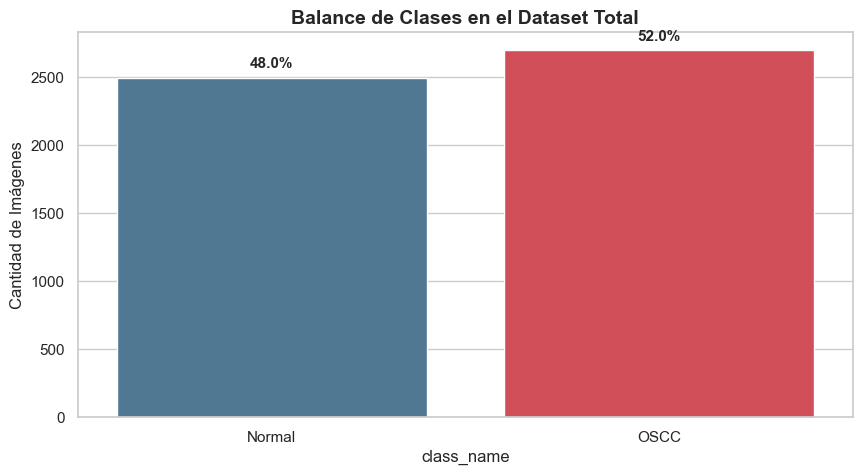

In [40]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_valid, x='class_name', palette=[PALETTE['normal'], PALETTE['cancer']])
plt.title('Balance de Clases en el Dataset Total', fontweight='bold')
plt.ylabel('Cantidad de Imágenes')

# Añadir etiquetas de porcentaje
total = len(df_valid)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')
plt.show()

---
## 5. Análisis de Resoluciones (Clusters 100x vs 400x)
Histopatología suele trabajar con aumentos específicos. Identificamos grupos por dimensiones.

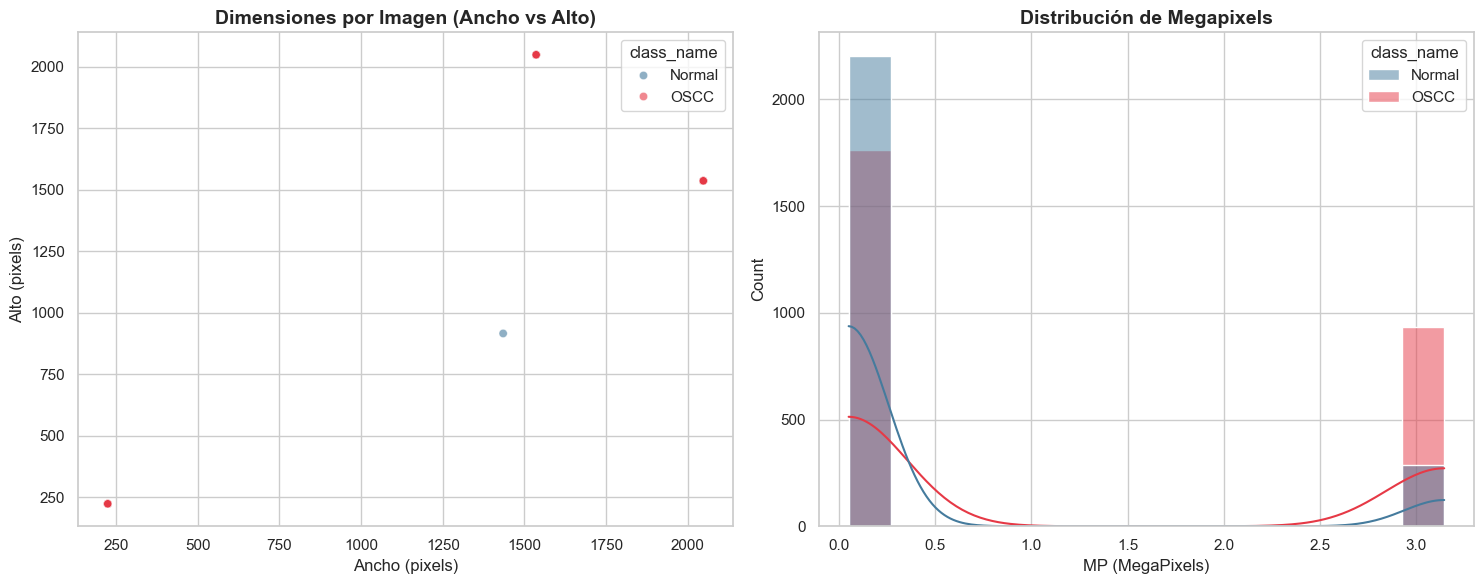

Clusters detectados (Magnificación):
width  height
224    224       3968
2048   1536       985
1536   2048       238
1435   916          1
dtype: int64


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot de dimensiones
sns.scatterplot(data=df_valid, x='width', y='height', hue='class_name', 
                alpha=0.6, palette=[PALETTE['normal'], PALETTE['cancer']], ax=ax1)
ax1.set_title('Dimensiones por Imagen (Ancho vs Alto)', fontweight='bold')
ax1.set_xlabel('Ancho (pixels)')
ax1.set_ylabel('Alto (pixels)')

# Histograma de Megapixels
sns.histplot(data=df_valid, x='megapixels', hue='class_name', kde=True, 
             palette=[PALETTE['normal'], PALETTE['cancer']], ax=ax2)
ax2.set_title('Distribución de Megapixels', fontweight='bold')
ax2.set_xlabel('MP (MegaPixels)')
plt.tight_layout()
plt.show()

print("Clusters detectados (Magnificación):")
print(df_valid.groupby(['width', 'height']).size().sort_values(ascending=False).head(5))

---
## 6. Análisis de Tamaño de Archivo y Compresión

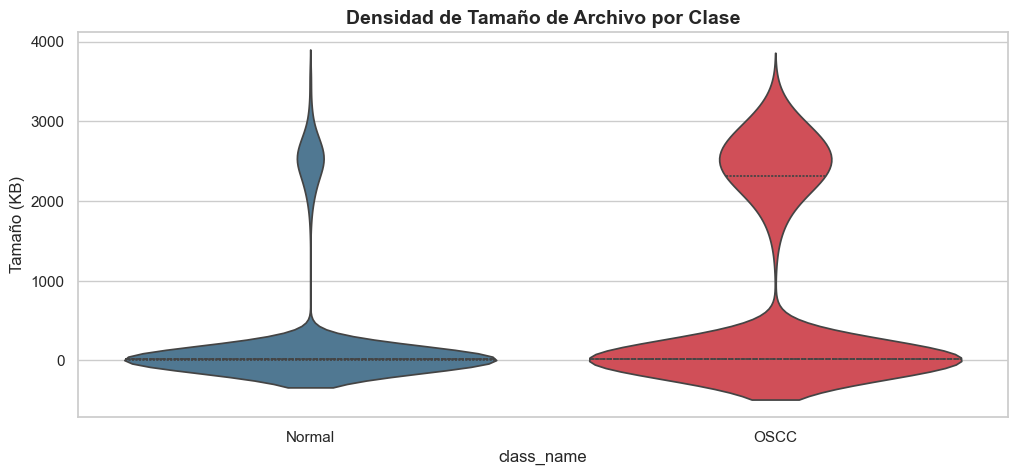

Tamaño promedio OSCC: 873.12 KB
Tamaño promedio Normal: 304.86 KB


In [42]:
plt.figure(figsize=(12, 5))
sns.violinplot(data=df_valid, x='class_name', y='file_size_kb', 
               palette=[PALETTE['normal'], PALETTE['cancer']], inner="quart")
plt.title('Densidad de Tamaño de Archivo por Clase', fontweight='bold')
plt.ylabel('Tamaño (KB)')
plt.show()

print(f"Tamaño promedio OSCC: {df_valid[df_valid['label']==1]['file_size_kb'].mean():.2f} KB")
print(f"Tamaño promedio Normal: {df_valid[df_valid['label']==0]['file_size_kb'].mean():.2f} KB")

---
## 7. Análisis de Color (Perfiles RGB)
El tinte de H&E (Eosina y Hematoxilina) tiene patrones específicos. Analizamos la media de cada canal.

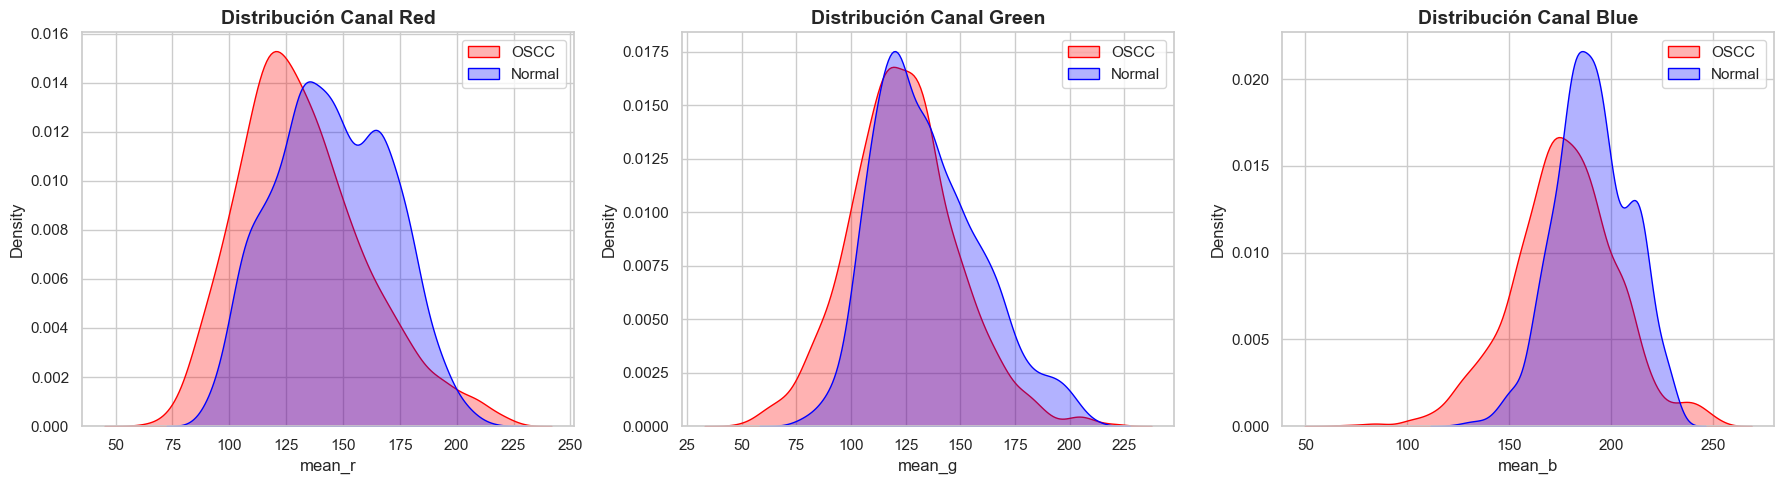

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = [('mean_r', 'Red', 'salmon'), ('mean_g', 'Green', 'lightgreen'), ('mean_b', 'Blue', 'skyblue')]

for i, (col, title, color) in enumerate(channels):
    sns.kdeplot(data=df_valid[df_valid['label']==1], x=col, color='red', label='OSCC', ax=axes[i], fill=True, alpha=0.3)
    sns.kdeplot(data=df_valid[df_valid['label']==0], x=col, color='blue', label='Normal', ax=axes[i], fill=True, alpha=0.3)
    axes[i].set_title(f'Distribución Canal {title}', fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

---
## 8. Diagnóstico de Calidad e Imágenes Problemáticas
Buscamos imágenes que puedan afectar negativamente el entrenamiento.

In [44]:
# Definir umbrales
BRIGHT_LOW = 40
BRIGHT_HIGH = 230
CONTRAST_LOW = 15

df_valid['flag_dark'] = df_valid['brightness'] < BRIGHT_LOW
df_valid['flag_overexposed'] = df_valid['brightness'] > BRIGHT_HIGH
df_valid['flag_low_contrast'] = df_valid['contrast'] < CONTRAST_LOW

problems = df_valid[['flag_dark', 'flag_overexposed', 'flag_low_contrast']].sum()
print("Hallazgos de calidad:")
for flag, count in problems.items():
    pct = (count / len(df_valid)) * 100
    print(f"- {flag}: {count} imágenes ({pct:.2f}%)")

Hallazgos de calidad:
- flag_dark: 0 imágenes (0.00%)
- flag_overexposed: 0 imágenes (0.00%)
- flag_low_contrast: 0 imágenes (0.00%)


---
## 9. Análisis Inferencial (Prueba Mann-Whitney)
¿Son las diferencias observadas significativas estadísticamente?

In [45]:
features = ['brightness', 'contrast', 'mean_r', 'mean_g', 'mean_b', 'megapixels', 'file_size_kb']
results = []

for feat in features:
    oscc_vals = df_valid[df_valid['label']==1][feat]
    normal_vals = df_valid[df_valid['label']==0][feat]
    stat, p_val = stats.mannwhitneyu(oscc_vals, normal_vals)
    results.append({'Feature': feat, 'p-value': p_val, 'Significativo': '✅' if p_val < 0.05 else '❌'})

inference_df = pd.DataFrame(results)
print("📊 Prueba de Mann-Whitney (Normal vs OSCC):")
print(inference_df.sort_values('p-value').to_string(index=False))

📊 Prueba de Mann-Whitney (Normal vs OSCC):
     Feature       p-value Significativo
  brightness 3.545349e-103             ✅
      mean_b 2.509889e-101             ✅
  megapixels  9.391985e-85             ✅
file_size_kb  5.999448e-80             ✅
      mean_r  2.805344e-71             ✅
      mean_g  1.324490e-49             ✅
    contrast  8.936136e-01             ❌


---
## 10. Galería de Muestras Histopatológicas

Muestras: Cáncer (OSCC)


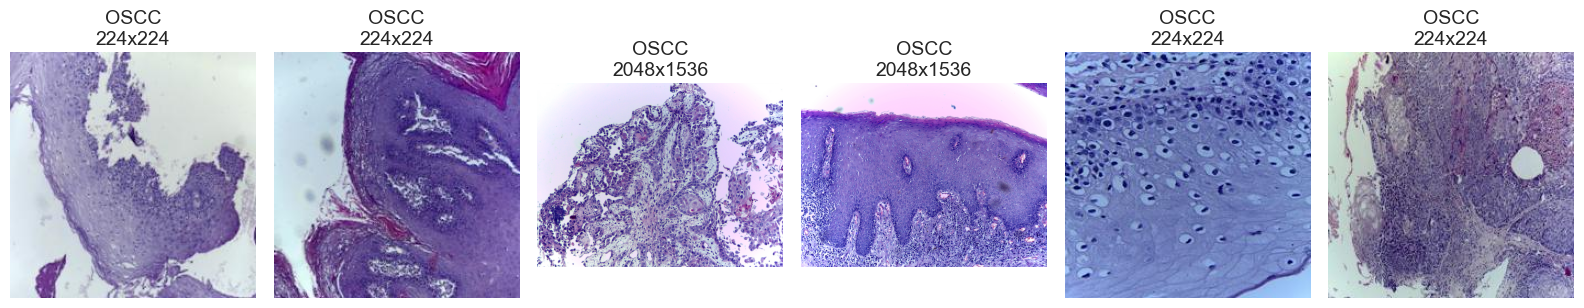

Muestras: Normal


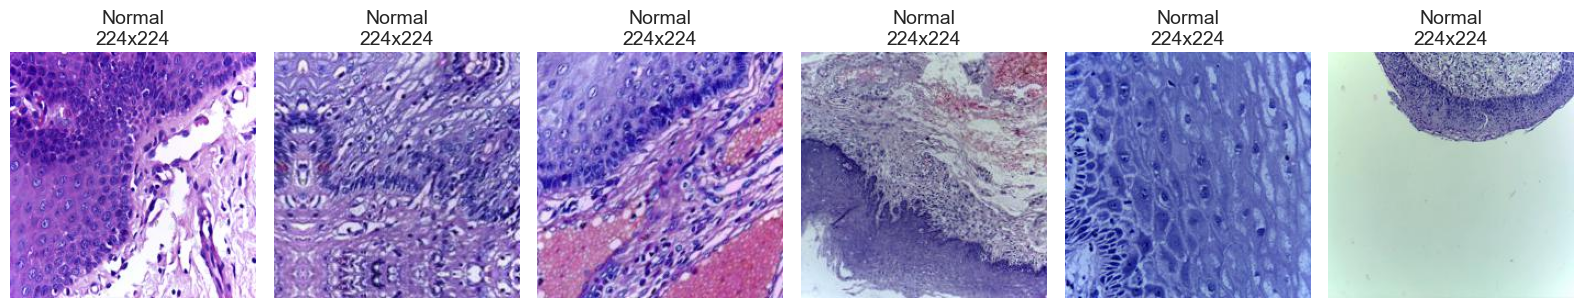

In [48]:
def show_samples(dataframe, label_name, n=6):
    samples = dataframe[dataframe['class_name'] == label_name].sample(n)
    plt.figure(figsize=(16, 4))
    for i, (_, row) in enumerate(samples.iterrows()):
        plt.subplot(1, n, i+1)
        img = Image.open(row['filepath'])
        plt.imshow(img)
        plt.title(f"{label_name}\n{row['width']}x{row['height']}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Muestras: Cáncer (OSCC)")
show_samples(df_valid, df_valid[df_valid['label']==1]['class_name'].iloc[0])

print("Muestras: Normal")
show_samples(df_valid, df_valid[df_valid['label']==0]['class_name'].iloc[0])

---
## 11. Resumen Ejecutivo de Hallazgos

In [49]:
summary_table = f"""
| Métrica | Resultado |
| :--- | :--- |
| **Total Imágenes** | {len(df_valid)} |
| **Balance de Clases** | {df_valid.class_name.value_counts(normalize=True).max()*100:.1f}% predominante |
| **Resoluciones Clave** | 2048x1536 y 224x224 predominantes |
| **Calidad de Datos** | {df_valid[['flag_dark', 'flag_overexposed', 'flag_low_contrast']].sum().sum()} imágenes con advertencias |
| **Recomendación Preprocesamiento** | Resize uniforme a 224x224 y normalización RGB |
"""
display(Markdown(summary_table))


| Métrica | Resultado |
| :--- | :--- |
| **Total Imágenes** | 5192 |
| **Balance de Clases** | 52.0% predominante |
| **Resoluciones Clave** | 2048x1536 y 224x224 predominantes |
| **Calidad de Datos** | 0 imágenes con advertencias |
| **Recomendación Preprocesamiento** | Resize uniforme a 224x224 y normalización RGB |
